### 1. 필요한 라이브러리 불러오기

데이터 처리 및 머신러닝 모델 학습에 필요한 라이브러리를 임포트합니다.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb # LightGBM 라이브러리 임포트
import time # 학습 시간 측정을 위한 time 라이브러리 임포트

print("라이브러리 불러오기 완료.")

라이브러리 불러오기 완료.


### 2. 전처리된 훈련 및 테스트 데이터 로드

`processed_5m` 폴더에서 `train_tabular_ML_opt.parquet`와 `test_tabular_ML_opt.parquet` 파일을 각각 로드합니다. 파일 경로와 이름을 실제 파일에 맞게 수정해주세요.

In [ ]:
import os

# Define paths for the new training files
RF_TRAIN_PATH = '/content/RandomForest_v2_train.parquet'
LGBM_TRAIN_PATH = '/content/LightGBM_v2_train.parquet'

try:
    # Load RandomForest training data
    if not os.path.exists(RF_TRAIN_PATH):
        raise FileNotFoundError(f"오류: '{RF_TRAIN_PATH}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    rf_train_df = pd.read_parquet(RF_TRAIN_PATH)
    print(f"RandomForest 훈련 데이터 로드 완료. 크기: {rf_train_df.shape}")
    display(rf_train_df.head())

    # Load LightGBM training data
    if not os.path.exists(LGBM_TRAIN_PATH):
        raise FileNotFoundError(f"오류: '{LGBM_TRAIN_PATH}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    lgbm_train_df = pd.read_parquet(LGBM_TRAIN_PATH)
    print(f"LightGBM 훈련 데이터 로드 완료. 크기: {lgbm_train_df.shape}")
    display(lgbm_train_df.head())

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"데이터 로드 중 오류가 발생했습니다: {e}")

RandomForest 훈련 데이터 로드 완료. 크기: (109378, 24)


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,...,remove_ratio,cart_purchase_ratio,n_categories,cat_entropy,n_brands,brand_loyalty,n_sessions,events_per_session,churn,user_id
0,5.213183,0.000000,1.0,1.0,1.0,0.0,0.0,0.0,7.140000,0.000000,...,0.000000,0.000000,1.0,-0.000000,1.0,1.000000,1.0,1.000000,1,9582366
1,3.775972,7.740116,4.0,46.0,28.0,13.0,5.0,0.0,6.456304,0.000000,...,0.384615,0.000000,10.0,1.836357,5.0,0.565217,6.0,7.666667,0,12961898
2,1.456053,0.004178,1.0,18.0,18.0,0.0,0.0,0.0,7.887222,0.000000,...,0.000000,0.000000,4.0,1.041979,4.0,0.333333,18.0,1.000000,1,16460232
3,2.288275,0.000810,1.0,2.0,0.0,2.0,0.0,0.0,5.015000,0.000000,...,0.000000,0.000000,1.0,-0.000000,2.0,0.500000,1.0,2.000000,1,17130461
4,2.271319,112.066597,20.0,584.0,396.0,77.0,104.0,7.0,5.467089,21.809999,...,1.350649,0.090909,43.0,2.579586,39.0,0.354452,1.0,584.000000,1,20554973


LightGBM 훈련 데이터 로드 완료. 크기: (109378, 24)


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,...,remove_ratio,cart_purchase_ratio,n_categories,cat_entropy,n_brands,brand_loyalty,n_sessions,events_per_session,churn,user_id
0,1.037588,-0.570657,-0.381893,-0.229514,-0.172473,-0.239848,-0.172354,-0.226933,-0.310354,-0.217670,...,-0.206210,-0.157407,-0.400673,-0.720979,-0.456811,0.804629,-0.087811,-0.145872,1,9582366
1,0.310066,-0.348351,0.131151,0.043558,0.125080,0.054999,-0.077937,-0.226933,-0.336385,-0.217670,...,0.197946,-0.157407,0.383437,1.224533,0.205375,-0.900903,-0.006322,0.078296,0,12961898
2,-0.864288,-0.570537,-0.381893,-0.126353,0.014875,-0.239848,-0.172354,-0.226933,-0.281905,-0.217670,...,-0.206210,-0.157407,-0.139303,0.382937,0.039828,-1.810520,0.189250,-0.145872,1,16460232
3,-0.443013,-0.570633,-0.381893,-0.223445,-0.183494,-0.194487,-0.172354,-0.226933,-0.391259,-0.217670,...,-0.206210,-0.157407,-0.400673,-0.720979,-0.291265,-1.156733,-0.087811,-0.112246,1,17130461
4,-0.451596,2.648037,2.867389,3.308285,4.180629,1.506551,1.791511,0.416353,-0.374047,0.191847,...,1.213060,0.028529,3.258508,2.011940,5.833960,-1.727677,-0.087811,19.457607,1,20554973


### 3. 훈련 및 테스트 데이터에서 특성과 타겟 분리

훈련 데이터(`train_df`)와 테스트 데이터(`test_df`) 각각에서 예측에 사용할 특성(X)과 예측하고자 하는 타겟(y)을 분리합니다. `target` 컬럼 이름을 실제 타겟 컬럼 이름으로 변경해야 합니다.

In [ ]:
if 'rf_train_df' in locals() and not rf_train_df.empty and 'lgbm_train_df' in locals() and not lgbm_train_df.empty:
    TARGET_COLUMN = 'churn' # Assuming 'churn' is still the target column

    # For RandomForest
    if TARGET_COLUMN in rf_train_df.columns:
        X_train_rf_raw = rf_train_df.drop(columns=[TARGET_COLUMN, 'user_id'], errors='ignore') # 'user_id'가 없을 경우 무시
        y_train_rf_raw = rf_train_df[TARGET_COLUMN]
        print(f"RandomForest 훈련 특성(X_train_rf_raw)과 타겟(y_train_rf_raw) 분리 완료. Shape: {X_train_rf_raw.shape}")
    else:
        print(f"오류: RandomForest 훈련 데이터에서 타겟 컬럼 '{TARGET_COLUMN}'을(를) 찾을 수 없습니다.")

    # For LightGBM
    if TARGET_COLUMN in lgbm_train_df.columns:
        X_train_lgbm_raw = lgbm_train_df.drop(columns=[TARGET_COLUMN, 'user_id'], errors='ignore')
        y_train_lgbm_raw = lgbm_train_df[TARGET_COLUMN]
        print(f"LightGBM 훈련 특성(X_train_lgbm_raw)과 타겟(y_train_lgbm_raw) 분리 완료. Shape: {X_train_lgbm_raw.shape}")
    else:
        print(f"오류: LightGBM 훈련 데이터에서 타겟 컬럼 '{TARGET_COLUMN}'을(를) 찾을 수 없습니다.")

    # Reset X_test, y_test as they are not provided for the new _v2 files.
    # User will need to provide them explicitly if final testing is desired.
    X_test = pd.DataFrame()
    y_test = pd.Series()
    print("주의: 새로운 파일에 대한 테스트 데이터가 제공되지 않았습니다. 최종 테스트를 위해 별도로 로드해야 합니다.")

else:
    print("오류: 훈련 데이터프레임이 로드되지 않았거나 비어있습니다. 이전 단계를 확인해주세요.")

RandomForest 훈련 특성(X_train_rf_raw)과 타겟(y_train_rf_raw) 분리 완료. Shape: (109378, 22)
LightGBM 훈련 특성(X_train_lgbm_raw)과 타겟(y_train_lgbm_raw) 분리 완료. Shape: (109378, 22)
주의: 새로운 파일에 대한 테스트 데이터가 제공되지 않았습니다. 최종 테스트를 위해 별도로 로드해야 합니다.


### 4. 훈련 데이터에서 검증 세트 분리

모델 개발 단계에서의 성능 평가를 위해 기존 `X_train`, `y_train` 데이터를 훈련 세트와 검증 세트(`X_val`, `y_val`)로 추가 분리합니다. 최종 테스트 데이터(`X_test`, `y_test`)는 별도로 유지됩니다.

In [ ]:
# RandomForest 모델을 위한 훈련/검증 세트
if 'X_train_rf_raw' in locals() and 'y_train_rf_raw' in locals():
    X_train_split_rf, X_val_rf, y_train_split_rf, y_val_rf = train_test_split(X_train_rf_raw, y_train_rf_raw, test_size=0.05, random_state=42, stratify=y_train_rf_raw)
    print(f"RandomForest 훈련 세트: {X_train_split_rf.shape}, 검증 세트: {X_val_rf.shape}")
else:
    print("오류: RandomForest 원본 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

# LightGBM 모델을 위한 훈련/검증 세트 (다른 random_state 사용)
if 'X_train_lgbm_raw' in locals() and 'y_train_lgbm_raw' in locals():
    X_train_split_lgbm, X_val_lgbm, y_train_split_lgbm, y_val_lgbm = train_test_split(X_train_lgbm_raw, y_train_lgbm_raw, test_size=0.05, random_state=43, stratify=y_train_lgbm_raw)
    print(f"LightGBM 훈련 세트: {X_train_split_lgbm.shape}, 검증 세트: {X_val_lgbm.shape}")
else:
    print("오류: LightGBM 원본 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

RandomForest 훈련 세트: (103909, 22), 검증 세트: (5469, 22)
LightGBM 훈련 세트: (103909, 22), 검증 세트: (5469, 22)


### 5.1. RandomForest 모델 훈련 (훈련 세트)

RandomForestClassifier 모델을 초기화하고 분리된 훈련 세트(`X_train_split`, `y_train_split`)로 학습시킵니다.

In [ ]:
if 'X_train_split_rf' in locals() and 'y_train_split_rf' in locals():
    # RandomForestClassifier를 사용합니다. 회귀 문제라면 RandomForestRegressor를 사용하세요.
    # 모델의 하이퍼파라미터는 필요에 따라 조정할 수 있습니다.
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    start_time = time.time() # 학습 시작 시간 기록
    model.fit(X_train_split_rf, y_train_split_rf) # RandomForest 전용 분리된 훈련 세트로 학습
    end_time = time.time() # 학습 종료 시간 기록
    rf_train_time_sec = end_time - start_time # 학습 시간 계산

    print("RandomForest 모델 훈련 완료.")
    print(f"RandomForest 모델 학습 시간: {rf_train_time_sec:.2f} 초")
else:
    print("오류: RandomForest 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

RandomForest 모델 훈련 완료.
RandomForest 모델 학습 시간: 33.46 초


### 5.2. RandomForest 모델 성능 평가 (검증 세트)

훈련된 RandomForest 모델의 성능을 평가합니다. accuracy, precision, recall, F1-score, ROC AUC, PR AUC, 혼동 행렬을 출력합니다.


--- RandomForest 모델 성능 평가 (검증 세트) ---
RandomForest 모델 정확도 (Accuracy): 0.8380

Classification Report (정밀도, 재현율, F1-Score):
              precision    recall  f1-score   support

           0       0.59      0.31      0.41       975
           1       0.86      0.95      0.91      4494

    accuracy                           0.84      5469
   macro avg       0.73      0.63      0.66      5469
weighted avg       0.81      0.84      0.82      5469

ROC AUC: 0.7830
PR AUC: 0.9368

Confusion Matrix (혼동 행렬):


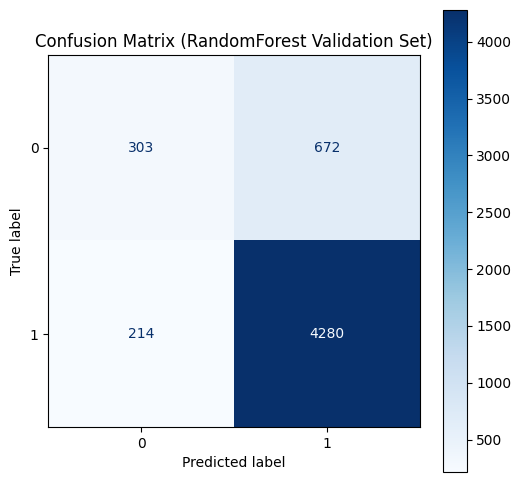

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'model' in locals() and 'X_val_rf' in locals() and 'y_val_rf' in locals():
    y_pred_rf_eval = model.predict(X_val_rf) # RandomForest 모델의 예측값

    print("\n--- RandomForest 모델 성능 평가 (검증 세트) ---")

    # 1. 정확도 (Accuracy)
    rf_accuracy = accuracy_score(y_val_rf, y_pred_rf_eval) # RandomForest 전용 검증 세트 사용
    print(f"RandomForest 모델 정확도 (Accuracy): {rf_accuracy:.4f}")

    # 2. 정밀도, 재현율, F1-Score (Classification Report)
    print("\nClassification Report (정밀도, 재현율, F1-Score):")
    print(classification_report(y_val_rf, y_pred_rf_eval)) # RandomForest 전용 검증 세트 사용

    # 확률 예측 (ROC AUC와 PR AUC 계산에 필요)
    if hasattr(model, 'predict_proba'):
        y_proba_rf_eval = model.predict_proba(X_val_rf) # RandomForest 전용 검증 세트로 예측 확률 계산
        # 이진 분류를 가정하고 양성 클래스(1)의 확률을 사용합니다.
        if y_proba_rf_eval.shape[1] == 2:
            y_proba_positive_rf_eval = y_proba_rf_eval[:, 1]

            # 3. ROC AUC
            try:
                rf_roc_auc = roc_auc_score(y_val_rf, y_proba_positive_rf_eval) # RandomForest 전용 검증 세트 사용
                print(f"ROC AUC: {rf_roc_auc:.4f}")
            except ValueError:
                print("ROC AUC를 계산할 수 없습니다. 타겟 클래스 분포를 확인하세요.")

            # 4. PR AUC
            precision_rf_eval, recall_rf_eval, _ = precision_recall_curve(y_val_rf, y_proba_positive_rf_eval) # RandomForest 전용 검증 세트 사용
            rf_pr_auc = auc(recall_rf_eval, precision_rf_eval)
            print(f"PR AUC: {rf_pr_auc:.4f}")
        else:
            print("predict_proba가 다중 클래스 예측을 반환합니다. ROC AUC와 PR AUC는 이진 분류에 일반적으로 사용됩니다.")
    else:
        print("모델이 확률 예측(predict_proba)을 지원하지 않습니다. ROC AUC와 PR AUC를 계산할 수 없습니다.")

    # 5. 혼동 행렬 (Confusion Matrix)
    print("\nConfusion Matrix (혼동 행렬):")
    fig_rf_cm, ax_rf_cm = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_estimator(model, X_val_rf, y_val_rf, cmap=plt.cm.Blues, ax=ax_rf_cm) # RandomForest 전용 검증 세트 사용
    plt.title('Confusion Matrix (RandomForest Validation Set)')
    plt.show()

else:
    print("오류: 모델 또는 RandomForest 검증 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

### 5.3. LightGBM 모델 훈련 (훈련 세트)

이전에 훈련한 RandomForest 모델과 별개로 LightGBM 모델을 학습하여 성능을 비교합니다. `X_train_split`과 `y_train_split`으로 모델을 훈련합니다.

In [ ]:
if 'X_train_split_lgbm' in locals() and 'y_train_split_lgbm' in locals():
    # LightGBM Classifier를 사용합니다.
    # 모델의 하이퍼파라미터는 필요에 따라 조정할 수 있습니다.
    lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)

    start_time_lgbm = time.time() # 학습 시작 시간 기록
    lgbm_model.fit(X_train_split_lgbm, y_train_split_lgbm) # LightGBM 전용 분리된 훈련 세트로 학습
    end_time_lgbm = time.time() # 학습 종료 시간 기록
    lgbm_train_time_sec = end_time_lgbm - start_time_lgbm # 학습 시간 계산

    print("LightGBM 모델 훈련 완료.")
    print(f"LightGBM 모델 학습 시간: {lgbm_train_time_sec:.2f} 초")
else:
    print("오류: LightGBM 훈련 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

[LightGBM] [Info] Number of positive: 85385, number of negative: 18524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5027
[LightGBM] [Info] Number of data points in the train set: 103909, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.821729 -> initscore=1.528103
[LightGBM] [Info] Start training from score 1.528103
LightGBM 모델 훈련 완료.
LightGBM 모델 학습 시간: 3.98 초


### 5.4. LightGBM 모델 성능 평가 (검증 세트)

훈련된 LightGBM 모델의 성능을 검증 세트(`X_val`, `y_val`)에서 평가합니다. accuracy, precision, recall, F1-score, ROC AUC, PR AUC, 혼동 행렬을 출력합니다.


--- LightGBM 모델 성능 평가 (검증 세트) ---
LightGBM 모델 정확도 (Accuracy): 0.8481

Classification Report (정밀도, 재현율, F1-Score):
              precision    recall  f1-score   support

           0       0.68      0.28      0.40       975
           1       0.86      0.97      0.91      4494

    accuracy                           0.85      5469
   macro avg       0.77      0.63      0.66      5469
weighted avg       0.83      0.85      0.82      5469

ROC AUC: 0.8053
PR AUC: 0.9386

Confusion Matrix (혼동 행렬):


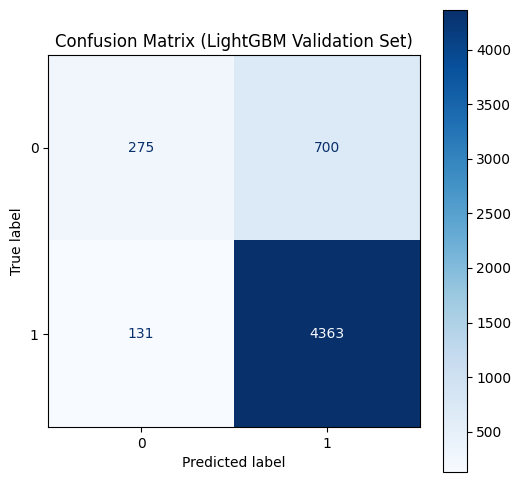

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'lgbm_model' in locals() and 'X_val_lgbm' in locals() and 'y_val_lgbm' in locals():
    y_pred_lgbm_eval = lgbm_model.predict(X_val_lgbm) # LightGBM 모델의 예측값

    print("\n--- LightGBM 모델 성능 평가 (검증 세트) ---")

    # 1. 정확도 (Accuracy)
    lgbm_accuracy = accuracy_score(y_val_lgbm, y_pred_lgbm_eval) # LightGBM 전용 검증 세트 사용
    print(f"LightGBM 모델 정확도 (Accuracy): {lgbm_accuracy:.4f}")

    # 2. 정밀도, 재현율, F1-Score (Classification Report)
    print("\nClassification Report (정밀도, 재현율, F1-Score):")
    print(classification_report(y_val_lgbm, y_pred_lgbm_eval)) # LightGBM 전용 검증 세트 사용

    # 확률 예측 (ROC AUC와 PR AUC 계산에 필요)
    if hasattr(lgbm_model, 'predict_proba'):
        y_proba_lgbm_eval = lgbm_model.predict_proba(X_val_lgbm) # LightGBM 전용 검증 세트로 예측 확률 계산
        # 이진 분류를 가정하고 양성 클래스(1)의 확률을 사용합니다.
        if y_proba_lgbm_eval.shape[1] == 2:
            y_proba_positive_lgbm_eval = y_proba_lgbm_eval[:, 1]

            # 3. ROC AUC
            try:
                lgbm_roc_auc = roc_auc_score(y_val_lgbm, y_proba_positive_lgbm_eval) # LightGBM 전용 검증 세트 사용
                print(f"ROC AUC: {lgbm_roc_auc:.4f}")
            except ValueError:
                print("ROC AUC를 계산할 수 없습니다. 타겟 클래스 분포를 확인하세요.")

            # 4. PR AUC
            precision_lgbm_eval, recall_lgbm_eval, _ = precision_recall_curve(y_val_lgbm, y_proba_positive_lgbm_eval) # LightGBM 전용 검증 세트 사용
            lgbm_pr_auc = auc(recall_lgbm_eval, precision_lgbm_eval)
            print(f"PR AUC: {lgbm_pr_auc:.4f}")
        else:
            print("predict_proba가 다중 클래스 예측을 반환합니다. ROC AUC와 PR AUC는 이진 분류에 일반적으로 사용됩니다.")
    else:
        print("모델이 확률 예측(predict_proba)을 지원하지 않습니다. ROC AUC와 PR AUC를 계산할 수 없습니다.")

    # 5. 혼동 행렬 (Confusion Matrix)
    print("\nConfusion Matrix (혼동 행렬):")
    fig_lgbm_cm, ax_lgbm_cm = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_estimator(lgbm_model, X_val_lgbm, y_val_lgbm, cmap=plt.cm.Blues, ax=ax_lgbm_cm) # LightGBM 전용 검증 세트 사용
    plt.title('Confusion Matrix (LightGBM Validation Set)')
    plt.show()

else:
    print("오류: LightGBM 모델 또는 LightGBM 검증 데이터가 준비되지 않았습니다. 이전 단계를 확인해주세요.")

### 5.5. 두 모델 성능 비교

RandomForest와 LightGBM 두 모델의 검증 세트 성능 지표와 학습 시간을 종합하여 비교표를 생성합니다.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# RandomForest 모델의 지표 추출 (평가 셀에서 저장된 변수 사용)
rf_accuracy_final = accuracy_score(y_val_rf, y_pred_rf_eval)
rf_precision_final = precision_score(y_val_rf, y_pred_rf_eval)
rf_recall_final = recall_score(y_val_rf, y_pred_rf_eval)
rf_f1_final = f1_score(y_val_rf, y_pred_rf_eval)
rf_roc_auc_final = roc_auc_score(y_val_rf, y_proba_positive_rf_eval)
rf_pr_auc_final = auc(recall_rf_eval, precision_rf_eval)

# LightGBM 모델의 지표 추출 (평가 셀에서 저장된 변수 사용)
lgbm_accuracy_final = accuracy_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_precision_final = precision_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_recall_final = recall_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_f1_final = f1_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_roc_auc_final = roc_auc_score(y_val_lgbm, y_proba_positive_lgbm_eval)
lgbm_pr_auc_final = auc(recall_lgbm_eval, precision_lgbm_eval)

# 결과 DataFrame 생성
results_df = pd.DataFrame({
    'model': ['RandomForest', 'LightGBM'],
    'accuracy': [rf_accuracy_final, lgbm_accuracy_final],
    'precision': [rf_precision_final, lgbm_precision_final],
    'recall': [rf_recall_final, lgbm_recall_final],
    'f1': [rf_f1_final, lgbm_f1_final],
    'roc_auc': [rf_roc_auc_final, lgbm_roc_auc_final],
    'pr_auc': [rf_pr_auc_final, lgbm_pr_auc_final],
    'train_time_sec': [rf_train_time_sec, lgbm_train_time_sec]
})

print("\n--- 모델 성능 비교 (검증 세트) ---")
display(results_df.round(4))


--- 모델 성능 비교 (검증 세트) ---


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_sec
0,RandomForest,0.8380,0.8643,0.9524,0.9062,0.7830,0.9368,33.4563
1,LightGBM,0.8481,0.8617,0.9709,0.9130,0.8053,0.9386,3.9767
